# **Notebook 3 — Evaluation and Paper Figures**
## Project 8 : Lightweight Transformer Surrogate for Thermal Field Reconstruction
### BASTION-LAB | Procedia Computer Science

**Metrics computed:**

| Metric | Symbol | Reference |
|--------|--------|-----------|
| Mean Absolute Error | MAE (K) | All papers |
| Root Mean Square Error | RMSE (K) | All papers |
| Maximum error | MaxErr (K) | Chen 2023, Yuan 2025 |
| Coefficient of determination | R² | Chen 2023, Li 2021 |
| Structural Similarity Index | SSIM | Ma 2024 |
| Hotspot MAE | MAE_hot (K) | KYA, Peng 2022 |
| Hotspot Detection Rate | HDR (%) | This work |
| Inference time | Time (ms) | Chen 2023, KYA |
| Noise robustness | MAE @ 1/3/5% | KYA, Yuan 2025 |
| Sensor dropout | MAE @ M=8/12/16 | KYA |
| Extreme cases | MAE_hard (K) | This work |


## **Step 1 — Imports and Setup**

In [ ]:
!pip -q install scipy matplotlib pandas scikit-image scikit-learn torch torchvision

import os, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from skimage.metrics import structural_similarity as sk_ssim
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Reproducibility + larger, legible figure fonts (reviewer R2 comment 7).
# NOTE: per-panel titles in the figure cells still set explicit fontsize=...
# and must be raised there too during the figure pass.
np.random.seed(42); torch.manual_seed(42)
plt.rcParams.update({
    'font.size': 13, 'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 12, 'figure.titlesize': 16, 'savefig.dpi': 200,
})
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : Tesla T4


## **Step 2 — Paths and Constants**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT     = '/content/drive/MyDrive/PaperSurrogate/paperReconstruction'
DATASET_ROOT   = os.path.join(DRIVE_ROOT, 'HEX_dataset')
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, 'checkpoints')
RESULTS_DIR    = os.path.join(DRIVE_ROOT, 'results1')
os.makedirs(RESULTS_DIR, exist_ok=True)

T_MIN, T_MAX = 280.0, 400.0
NY, NX       = 64, 128
CMAP         = 'RdYlBu_r'    # blue=cold, yellow/red=hot (KYA convention)

def to_kelvin(x):
    """Convert normalized [0,1] value/tensor/array back to Kelvin."""
    return x * (T_MAX - T_MIN) + T_MIN

print("Checkpoints available:")
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    size_mb = os.path.getsize(os.path.join(CHECKPOINT_DIR, f)) / 1e6
    print(f"  {f:<30} {size_mb:.1f} MB")

Mounted at /content/drive
Checkpoints available:
  fno_best.pth                   4.8 MB
  mlp_best.pth                   111.8 MB
  unet_best.pth                  7.8 MB
  vit_best.pth                   3.1 MB


## **Step 3 — Dataset with Noise and Dropout Built-in**
The dataset returns 4 values: normalized input, normalized target, sensor positions, raw Kelvin target.
Noise and dropout are applied directly at dataset level — cleaner than post-hoc manipulation.

In [ ]:
class HEXDataset(Dataset):
    """
    Evaluation dataset loader with built-in noise and dropout augmentation.

    Args:
        root_dir        (str)  : path to test/ folder
        n_sensors       (int)  : subsample to N sensors (None = use all stored)
        add_noise_std   (float): Gaussian noise level as fraction of T_range (e.g. 0.03 = 3%)
        dropout_sensors (int)  : number of sensors to randomly remove (0 = no dropout)
        hard_only       (bool) : if True, load only hard_*.mat files
        lhs_only        (bool) : if True, load only sample_*.mat files

    Returns per sample:
        X_norm   : (3, 64, 128) normalized Strategy A image
        T_norm   : (1, 64, 128) normalized ground truth
        upos     : (M, 2) sensor positions
        T_kelvin : (1, 64, 128) raw ground truth in Kelvin (for metrics)
    """
    def __init__(self, root_dir, n_sensors=None, add_noise_std=0.0,
                 dropout_sensors=0, hard_only=False, lhs_only=False):
        files = sorted([f for f in os.listdir(root_dir) if f.endswith('.mat')])
        if hard_only:
            files = [f for f in files if f.startswith('hard_')]
        elif lhs_only:
            files = [f for f in files if f.startswith('sample_')]
        self.files          = [os.path.join(root_dir, f) for f in files]
        self.n_sensors      = n_sensors
        self.add_noise_std  = add_noise_std
        self.dropout_sensors = dropout_sensors
        print(f"  Loaded {len(self.files)} samples from '{root_dir}'")

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        d = sio.loadmat(self.files[idx])
        T       = d['T_field'].squeeze().astype(np.float32)   # raw Kelvin
        pos     = d['u_pos'].squeeze()
        params  = d['params'].squeeze().astype(np.float32)
        if pos.ndim == 1: pos = pos[np.newaxis, :]

        # Sensor subsampling (dropout study M=8/12/16)
        if self.n_sensors is not None:
            keep = np.random.choice(pos.shape[0], self.n_sensors, replace=False)
            pos  = pos[keep]

        # Sensor dropout (robustness: remove N random sensors)
        if self.dropout_sensors > 0:
            n_keep = max(1, pos.shape[0] - self.dropout_sensors)
            keep   = np.random.choice(pos.shape[0], n_keep, replace=False)
            pos    = pos[keep]

        # Read sensor temperatures
        obs = np.array([T[r, c] for r, c in pos], dtype=np.float32)

        # Add Gaussian noise to sensor readings
        if self.add_noise_std > 0:
            sigma = self.add_noise_std * (T_MAX - T_MIN)
            obs   = obs + np.random.normal(0.0, sigma, size=obs.shape).astype(np.float32)

        # Build Strategy A sparse image
        X = np.zeros((3, NY, NX), dtype=np.float32)
        for val, (r, c) in zip(obs, pos):
            X[0, r, c] = val
            X[1, r, c] = 1.0
        X[2, :, :] = float(params[0])

        # Normalize to [0, 1] with safety clip
        X[0] = (X[0] - T_MIN) / (T_MAX - T_MIN)
        X[2] = (X[2] - T_MIN) / (T_MAX - T_MIN)
        T_norm = (T - T_MIN) / (T_MAX - T_MIN)
        X      = np.clip(X, 0.0, 1.0)
        T_norm = np.clip(T_norm, 0.0, 1.0)

        return (torch.from_numpy(X),
                torch.from_numpy(T_norm[None, ...]),
                pos,
                torch.from_numpy(T[None, ...]))   # raw Kelvin for metrics


def get_test_loader(batch_size=16, seed=42, **kwargs):
    # Reseed so noise/dropout draws are reproducible across runs; num_workers=0
    # keeps the RNG stream deterministic (worker processes would re-seed it).
    np.random.seed(seed); torch.manual_seed(seed)
    ds = HEXDataset(os.path.join(DATASET_ROOT, 'test'), **kwargs)
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                     num_workers=0, pin_memory=torch.cuda.is_available())

# Quick check
loader = get_test_loader(batch_size=4, lhs_only=True)
X, Tn, pos, Tk = next(iter(loader))
print(f"X      : {tuple(X.shape)}   range [{X.min():.3f}, {X.max():.3f}]")
print(f"T_norm : {tuple(Tn.shape)}  range [{Tn.min():.3f}, {Tn.max():.3f}]")
print(f"T_K    : {tuple(Tk.shape)}  range [{Tk.min():.1f}, {Tk.max():.1f}] K")

  Loaded 500 samples from '/content/drive/MyDrive/PaperSurrogate/paperReconstruction/HEX_dataset/test'
X      : (4, 3, 64, 128)   range [0.000, 1.000]
T_norm : (4, 1, 64, 128)  range [0.023, 0.907]
T_K    : (4, 1, 64, 128)  range [282.7, 388.9] K


## **Step 4 — Model Definitions**

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.block(x)

class MLP(nn.Module):
    def __init__(self, ny=64, nx=128):
        super().__init__(); self.ny, self.nx = ny, nx
        self.net = nn.Sequential(
            nn.Linear(3*ny*nx,1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(1024,512),     nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512,256),      nn.BatchNorm1d(256),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256,ny*nx),    nn.Sigmoid())
    def forward(self, x):
        return self.net(x.reshape(x.shape[0],-1)).reshape(x.shape[0],1,self.ny,self.nx)

class UNet(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        self.enc1=ConvBlock(in_ch,base); self.enc2=ConvBlock(base,base*2)
        self.enc3=ConvBlock(base*2,base*4); self.pool=nn.MaxPool2d(2)
        self.bot=ConvBlock(base*4,base*8)
        self.up3=nn.ConvTranspose2d(base*8,base*4,2,stride=2); self.dec3=ConvBlock(base*8,base*4)
        self.up2=nn.ConvTranspose2d(base*4,base*2,2,stride=2); self.dec2=ConvBlock(base*4,base*2)
        self.up1=nn.ConvTranspose2d(base*2,base,2,stride=2);   self.dec1=ConvBlock(base*2,base)
        self.head=nn.Sequential(nn.Conv2d(base,1,1),nn.Sigmoid())
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2))
        b=self.bot(self.pool(e3))
        return self.head(self.dec1(torch.cat([self.up1(
            self.dec2(torch.cat([self.up2(
                self.dec3(torch.cat([self.up3(b),e3],1))),e2],1))),e1],1)))

class TinyViT(nn.Module):
    def __init__(self, in_ch=3, base=32, d=64, n_heads=4, n_layers=3):
        super().__init__()
        self.enc1=ConvBlock(in_ch,base); self.enc2=ConvBlock(base,base*2)
        self.enc3=ConvBlock(base*2,base*4); self.pool=nn.MaxPool2d(2)
        self.bot=nn.Sequential(
            nn.Conv2d(base*4,d,3,padding=1,bias=False),nn.BatchNorm2d(d),nn.GELU(),
            nn.Conv2d(d,d,3,padding=1,bias=False),nn.BatchNorm2d(d),nn.GELU())
        self.pos_emb=nn.Parameter(torch.zeros(1,128,d))
        nn.init.trunc_normal_(self.pos_emb,std=0.02)
        el=nn.TransformerEncoderLayer(d,n_heads,d*2,0.1,'gelu',batch_first=True,norm_first=True)
        self.transformer=nn.TransformerEncoder(el,n_layers); self.norm=nn.LayerNorm(d)
        self.proj=nn.Conv2d(d,base*4,1,bias=False)
        self.up3=nn.ConvTranspose2d(base*4,base*2,2,stride=2); self.dec3=ConvBlock(base*2+base*4,base*2)
        self.up2=nn.ConvTranspose2d(base*2,base,2,stride=2);   self.dec2=ConvBlock(base+base*2,base)
        self.up1=nn.ConvTranspose2d(base,base//2,2,stride=2);  self.dec1=ConvBlock(base//2+base,base//2)
        self.head=nn.Sequential(nn.Conv2d(base//2,1,1),nn.Sigmoid())
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2))
        b=self.bot(self.pool(e3)); B,C,H,W=b.shape
        tok=self.norm(self.transformer(b.flatten(2).permute(0,2,1)+self.pos_emb))
        feat=self.proj(tok.permute(0,2,1).view(B,C,H,W))
        d3=self.dec3(torch.cat([self.up3(feat),e3],1))
        d2=self.dec2(torch.cat([self.up2(d3),e2],1))
        return self.head(self.dec1(torch.cat([self.up1(d2),e1],1)))

class SpectralConv2d(nn.Module):
    def __init__(self,i,o,m1=12,m2=12):
        super().__init__(); s=1/(i*o)
        self.W1=nn.Parameter(s*torch.randn(i,o,m1,m2))
        self.W2=nn.Parameter(s*torch.randn(i,o,m1,m2)); self.m1,self.m2=m1,m2
    def forward(self,x):
        B,_,NY,NX=x.shape; xf=torch.fft.rfft2(x)
        out=torch.zeros(B,self.W1.shape[1],NY,NX//2+1,dtype=torch.complex64,device=x.device)
        out[:,:,:self.m1,:self.m2]=torch.einsum('bixy,ioxy->boxy',
            xf[:,:,:self.m1,:self.m2],torch.complex(self.W1,self.W2))
        return torch.fft.irfft2(out,s=(NY,NX))

class FNOLite(nn.Module):
    def __init__(self,in_ch=3,d=32,n_layers=4,m1=12,m2=12):
        super().__init__(); self.lift=nn.Conv2d(in_ch,d,1)
        self.spec=nn.ModuleList([SpectralConv2d(d,d,m1,m2) for _ in range(n_layers)])
        self.pw=nn.ModuleList([nn.Conv2d(d,d,1) for _ in range(n_layers)])
        self.bn=nn.ModuleList([nn.BatchNorm2d(d) for _ in range(n_layers)])
        self.proj=nn.Sequential(nn.Conv2d(d,d//2,1),nn.GELU(),nn.Conv2d(d//2,1,1),nn.Sigmoid())
    def forward(self,x):
        x=self.lift(x)
        for s,p,b in zip(self.spec,self.pw,self.bn): x=F.gelu(b(s(x)+p(x)))
        return self.proj(x)

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print("Model classes defined.")

Model classes defined.


## **Step 5 — Load Checkpoints**

In [ ]:
def load_ckpt(ckpt_name, model_cls):
    path  = os.path.join(CHECKPOINT_DIR, ckpt_name)
    ckpt  = torch.load(path, map_location=device, weights_only=False)
    model = model_cls().to(device)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    print(f"  {ckpt_name:<25} epoch={ckpt['epoch']:3d}  val MAE={ckpt['val_mae_K']:.3f}K  "
          f"params={count_params(model)/1e6:.2f}M")
    return model

print("Loading checkpoints...")
models = {
    'MLP'      : load_ckpt('mlp_best.pth',  MLP),
    'U-Net'    : load_ckpt('unet_best.pth', UNet),
    'Tiny ViT' : load_ckpt('vit_best.pth',  TinyViT),
    'FNO-lite' : load_ckpt('fno_best.pth',  FNOLite),
}
MODEL_NAMES = ['RBF', 'MLP', 'U-Net', 'Tiny ViT', 'FNO-lite']
print("Done.")

Loading checkpoints...
  mlp_best.pth              epoch=  1  val MAE=7.157K  params=27.93M
  unet_best.pth             epoch=182  val MAE=0.604K  params=1.93M
  vit_best.pth              epoch=181  val MAE=0.407K  params=0.75M
  fno_best.pth              epoch=163  val MAE=3.365K  params=1.18M
Done.


## **Step 6 — Metric Functions**
All metrics operate on Kelvin arrays. SSIM uses the scikit-image reference implementation.
HDR (Hotspot Detection Rate) measures what fraction of true hotspot pixels are correctly identified.

In [ ]:

# ── Grid for RBF ─────────────────────────────────────────────────────────────
_grid = np.stack(np.meshgrid(np.arange(NY),np.arange(NX),indexing='ij'),
                 axis=-1).reshape(-1,2).astype(float)

def rbf_predict(x_denorm, kernel='thin_plate_spline', smoothing=1e-3):
    """Classical RBF reconstruction (untrained baseline) from a denormalized
    (3, NY, NX) Strategy A input.

    ROBUSTNESS FIX. The previous version used an unsmoothed cubic kernel with no
    bounding. For steep high-Peclet fields and certain random sensor placements
    (including coincident sensor pixels produced by np.random.randint), the
    interpolation system becomes ill-conditioned and the cubic kernel
    extrapolates to non-physical values (up to ~1e9 K). A handful of such
    samples was enough to drive the aggregate RBF error to ~4e4 K. We now:
      (1) deduplicate coincident sensor pixels (average their readings),
      (2) use a thin-plate-spline kernel with a degree-1 polynomial trend and a
          small smoothing term (Tikhonov regularization),
      (3) clamp the field to the physically admissible range [T_MIN, T_MAX].
    RBF stays a learning-free lower bound; the numerical blow-up is removed.
    """
    rows, cols = np.where(x_denorm[1] > 0.5)
    fill = float(x_denorm[2, 0, 0])                 # broadcast T_in = sane fallback
    if len(rows) < 3:
        return np.full((NY, NX), fill, dtype=np.float32)
    # (1) deduplicate coincident sensor pixels
    pts_all  = np.stack([rows, cols], axis=1).astype(float)
    vals_all = x_denorm[0, rows, cols].astype(float)
    pts, inv = np.unique(pts_all, axis=0, return_inverse=True)
    vals = np.zeros(len(pts)); cnt = np.zeros(len(pts))
    np.add.at(vals, inv, vals_all); np.add.at(cnt, inv, 1.0); vals /= cnt
    if len(pts) < 3:
        return np.full((NY, NX), fill, dtype=np.float32)
    # (2) regularized thin-plate-spline RBF with linear polynomial trend
    try:
        rbf  = RBFInterpolator(pts, vals, kernel=kernel,
                               smoothing=smoothing, degree=1)
        pred = rbf(_grid).reshape(NY, NX)
    except Exception:
        pred = np.full((NY, NX), fill)
    # (3) finite guard + physical clamp
    pred = np.where(np.isfinite(pred), pred, fill)
    return np.clip(pred, T_MIN, T_MAX).astype(np.float32)


def mae_K(pred, target):
    return float(np.mean(np.abs(pred - target)))

def rmse_K(pred, target):
    return float(np.sqrt(np.mean((pred - target)**2)))

def max_error_K(pred, target):
    return float(np.max(np.abs(pred - target)))

def r2(pred, target):
    return float(r2_score(target.ravel(), pred.ravel()))

def ssim_metric(pred, target):
    """
    Structural Similarity Index via scikit-image (reference implementation).
    Measures luminance, contrast, and structure simultaneously.
    SSIM in [0, 1]; 1 = perfect match.
    Reference: Ma et al. 2024, Sensors 24(20):6564.
    """
    data_range = max(1e-6, float(target.max() - target.min()))
    return float(sk_ssim(target, pred, data_range=data_range))

def hotspot_mae(pred, target):
    """
    MAE restricted to hotspot pixels (T > mean + std).
    These are the industrially critical zones.
    Reference: KYA Section 4.8, Peng et al. 2022.
    """
    mask = target > (target.mean() + target.std())
    if mask.sum() == 0: return float('nan')
    return float(np.mean(np.abs(pred[mask] - target[mask])))

def hotspot_detection_rate(pred, target):
    """
    Fraction of true hotspot pixels also detected as hotspots in prediction.
    HDR = |pred_hot ∩ true_hot| / |true_hot|
    HDR = 1.0 means all hotspot zones are correctly identified.
    """
    true_mask = target > (target.mean() + target.std())
    pred_mask = pred   > (pred.mean()   + pred.std())
    denom     = true_mask.sum()
    if denom == 0: return float('nan')
    return float((pred_mask & true_mask).sum() / denom)

def infer_ms(model, x_sample, n_warmup=10, n_runs=50):
    """
    Accurate inference time measurement.
    Warm-up runs are discarded; timing covers the full n_runs block
    with a single cuda.synchronize() for accuracy.
    """
    x = x_sample.to(device)
    with torch.no_grad():
        for _ in range(n_warmup): model(x)   # warm up GPU
        if device.type == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_runs): model(x)
        if device.type == 'cuda': torch.cuda.synchronize()
    return 1000.0 * (time.perf_counter() - t0) / n_runs

print("Metric functions defined.")

Metric functions defined.


## **Step 7 — Main Evaluation (LHS Test Set)**
Batch evaluation on the 500 LHS test samples. Results include all metrics.

In [ ]:
def run_eval(loader, include_rbf=True, label=''):
    """
    Batch evaluation of all models on a DataLoader.
    Returns a DataFrame with one row per model.
    """
    sample_x = next(iter(loader))[0][:1]   # for timing

    # Accumulate per-sample predictions
    agg_preds   = {n: [] for n in MODEL_NAMES}
    agg_targets = []

    for X, _, _, T_kelvin in loader:
        T_kelvin_np = T_kelvin.numpy()[:, 0]   # (B, NY, NX)
        for i in range(X.shape[0]):
            agg_targets.append(T_kelvin_np[i])

        if include_rbf:
            for i in range(X.shape[0]):
                x_dn = X[i].numpy().copy()
                x_dn[0] = x_dn[0]*(T_MAX-T_MIN)+T_MIN
                x_dn[2] = x_dn[2]*(T_MAX-T_MIN)+T_MIN
                agg_preds['RBF'].append(rbf_predict(x_dn))

        with torch.no_grad():
            X_dev = X.to(device)
            for name, model in models.items():
                preds_K = model(X_dev).cpu().numpy()[:,0] * (T_MAX-T_MIN) + T_MIN
                for p in preds_K:
                    agg_preds[name].append(p)

    # Aggregate metrics per model
    records = []
    for name in (MODEL_NAMES if include_rbf else list(models.keys())):
        preds   = np.stack(agg_preds[name])   # (N, NY, NX)
        targets = np.stack(agg_targets)        # (N, NY, NX)
        row = {
            'Model'       : name,
            'MAE (K)'     : mae_K(preds, targets),
            'RMSE (K)'    : rmse_K(preds, targets),
            'MaxErr (K)'  : max_error_K(preds, targets),
            'R2'          : r2(preds, targets),
            'SSIM'        : float(np.nanmean([ssim_metric(p,t) for p,t in zip(preds,targets)])),
            'HotMAE (K)'  : float(np.nanmean([hotspot_mae(p,t) for p,t in zip(preds,targets)])),
            'HDR (%)'     : float(np.nanmean([hotspot_detection_rate(p,t) for p,t in zip(preds,targets)]))*100,
            'Time (ms)'   : 0.0 if name=='RBF' else infer_ms(models[name], sample_x),
            'Params (M)'  : 0 if name=='RBF' else round(count_params(models[name])/1e6, 2),
        }
        if name == 'RBF':
            x_dn = sample_x[0].numpy().copy()
            x_dn[0] = x_dn[0]*(T_MAX-T_MIN)+T_MIN
            x_dn[2] = x_dn[2]*(T_MAX-T_MIN)+T_MIN
            n_rep = 20
            t0 = time.perf_counter()
            for _ in range(n_rep):
                rbf_predict(x_dn)
            row['Time (ms)'] = (time.perf_counter()-t0)/n_rep*1000
        records.append(row)

    df = pd.DataFrame(records)
    if label: print(f"\n=== {label} ===")
    print(df[['Model','MAE (K)','RMSE (K)','MaxErr (K)','R2','SSIM',
              'HotMAE (K)','HDR (%)','Time (ms)']].to_string(index=False))
    return df, agg_preds, agg_targets


# Run main evaluation on LHS test samples
base_loader  = get_test_loader(batch_size=16, lhs_only=True)
results_df, all_preds, all_targets = run_eval(base_loader, include_rbf=True,
                                               label='Standard Test Set (LHS)')
results_df.to_csv(os.path.join(RESULTS_DIR, 'results_main.csv'), index=False)
# Canonical numeric table (single source of truth for the paper).
# Supersedes the stale results_table.csv/.tex committed earlier.
results_df.to_csv(os.path.join(RESULTS_DIR, 'results_table.csv'), index=False)

  Loaded 500 samples from '/content/drive/MyDrive/PaperSurrogate/paperReconstruction/HEX_dataset/test'

=== Standard Test Set (LHS) ===
   Model  MAE (K)  RMSE (K)  MaxErr (K)       R2     SSIM  HotMAE (K)   HDR (%)  Time (ms)
     RBF 7.403167 15.637497  119.891327 0.676296 0.786348    9.712038 55.236231   3.282300
     MLP 7.063001 10.140718   72.530487 0.863871 0.906049    6.699464 91.046770   0.525106
   U-Net 0.597143  1.157710   32.564880 0.998226 0.994416    0.624543 98.112470   1.815251
Tiny ViT 0.407556  0.717749   25.664764 0.999318 0.995970    0.500048 98.731813   3.194240
FNO-lite 3.244028  7.241840  113.164520 0.930576 0.934570    5.419366 87.919710   1.978888


## **Step 8 — Robustness Study (Noise + Dropout + Hard Cases)**

In [ ]:
def robustness_study():
    """
    Evaluate DL models under 3 types of perturbation:
    1. Gaussian noise on sensor readings: 1%, 3%, 5% of 120K range
    2. Sensor dropout: remove 1, 2, 4 sensors
    3. Hard/extreme parameter configurations (50 samples)
    """
    rows = []

    # Noise study
    for noise in [0.01, 0.03, 0.05]:
        loader = get_test_loader(batch_size=16, lhs_only=True, add_noise_std=noise)
        df, _, _ = run_eval(loader, include_rbf=False,
                            label=f'Noise {int(noise*100)}%')
        for _, r in df.iterrows():
            rows.append({'Setting': f'Noise {int(noise*100)}%',
                         'Model': r['Model'], 'MAE (K)': r['MAE (K)']})

    # Sensor dropout study (M=8, 12, 16)
    for M in [8, 12, 16]:
        loader = get_test_loader(batch_size=16, lhs_only=True, n_sensors=M)
        df, _, _ = run_eval(loader, include_rbf=False, label=f'M={M} sensors')
        for _, r in df.iterrows():
            rows.append({'Setting': f'M={M} sensors',
                         'Model': r['Model'], 'MAE (K)': r['MAE (K)']})

    # Hard/extreme cases
    hard_loader = get_test_loader(batch_size=8, hard_only=True)
    df_hard, _, _ = run_eval(hard_loader, include_rbf=False, label='Hard cases')
    for _, r in df_hard.iterrows():
        rows.append({'Setting': 'Hard cases',
                     'Model': r['Model'], 'MAE (K)': r['MAE (K)']})

    return pd.DataFrame(rows)


robustness_df = robustness_study()
robustness_df.to_csv(os.path.join(RESULTS_DIR, 'results_robustness.csv'), index=False)
print("\nRobustness pivot table:")
print(robustness_df.pivot(index='Setting', columns='Model', values='MAE (K)').to_string())

  Loaded 500 samples from '/content/drive/MyDrive/PaperSurrogate/paperReconstruction/HEX_dataset/test'

=== Noise 1% ===
   Model  MAE (K)  RMSE (K)  MaxErr (K)       R2     SSIM  HotMAE (K)   HDR (%)  Time (ms)
     MLP 7.063007 10.140716   72.530670 0.863871 0.906050    6.699469 91.046878   0.584348
   U-Net 0.983381  1.550639   34.577515 0.996817 0.992343    0.842425 97.380468   2.295307
Tiny ViT 0.655394  0.988699   26.581360 0.998706 0.995325    0.647384 98.532967   3.991749
FNO-lite 3.295030  7.279790  112.704590 0.929846 0.933970    5.457649 87.766247   5.505581
  Loaded 500 samples from '/content/drive/MyDrive/PaperSurrogate/paperReconstruction/HEX_dataset/test'

=== Noise 3% ===
   Model  MAE (K)  RMSE (K)  MaxErr (K)       R2     SSIM  HotMAE (K)   HDR (%)  Time (ms)
     MLP 7.063014 10.140706   72.530975 0.863871 0.906050    6.699482 91.046782   1.706613
   U-Net 2.265775  3.289875   50.916656 0.985672 0.976774    1.688771 94.386292   2.750726
Tiny ViT 1.662540  2.555276   

## **Step 9 — Reconstruction Comparison Figure**

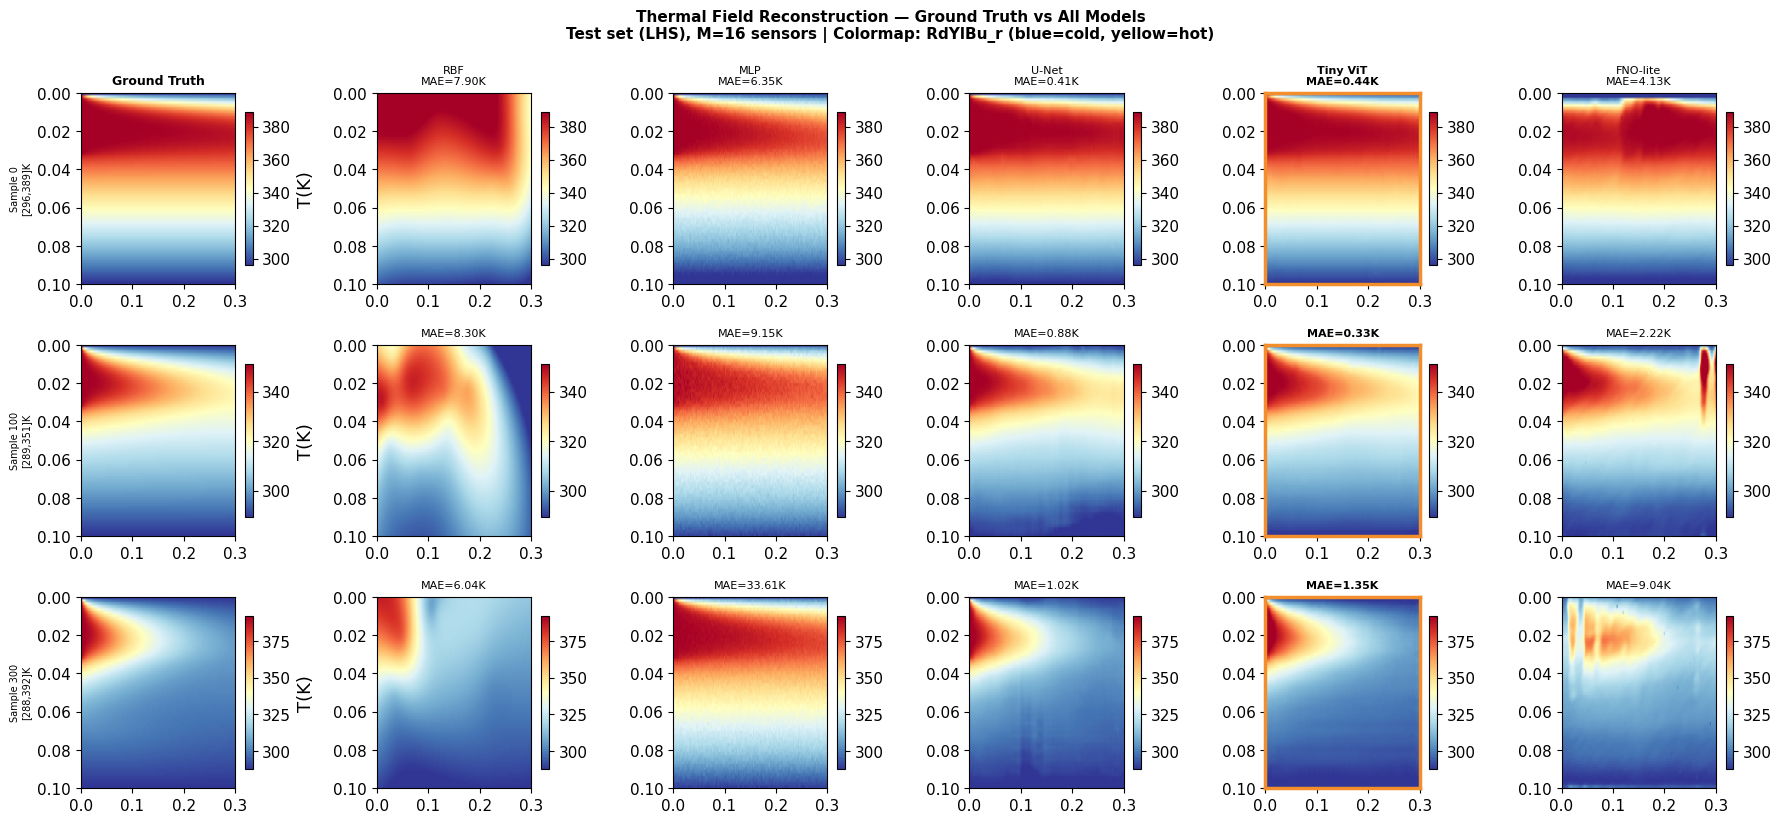

Saved: /content/drive/MyDrive/PaperSurrogate/paperReconstruction/results1/reconstruction_comparison.png


In [ ]:
sample_ids = [0, 100, 300]
extent     = [0, 0.3, 0.1, 0]
n_models   = len(MODEL_NAMES)

fig, axes = plt.subplots(len(sample_ids), n_models+1,
                          figsize=((n_models+1)*3.0, len(sample_ids)*2.8))
fig.suptitle('Thermal Field Reconstruction — Ground Truth vs All Models\n'
             'Test set (LHS), M=16 sensors | Colormap: RdYlBu_r (blue=cold, yellow=hot)',
             fontsize=11, fontweight='bold')

for row, sid in enumerate(sample_ids):
    target_K = all_targets[sid]
    vmin, vmax = target_K.min(), target_K.max()

    ax = axes[row, 0]
    im = ax.imshow(target_K, cmap=CMAP, origin='upper',
                   extent=extent, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_title('Ground Truth' if row==0 else '', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'Sample {sid}\n[{vmin:.0f},{vmax:.0f}]K', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8, label='T(K)')

    for col, name in enumerate(MODEL_NAMES):
        ax   = axes[row, col+1]
        pred = all_preds[name][sid]
        mae  = np.abs(pred - target_K).mean()
        im   = ax.imshow(pred, cmap=CMAP, origin='upper',
                         extent=extent, aspect='auto', vmin=vmin, vmax=vmax)
        title = (name if row==0 else '') + f'\nMAE={mae:.2f}K'
        ax.set_title(title.strip(), fontsize=8,
                     fontweight='bold' if name=='Tiny ViT' else 'normal')
        if name == 'Tiny ViT':
            for sp in ax.spines.values():
                sp.set_edgecolor('#f28e2b'); sp.set_linewidth(2.5)
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'reconstruction_comparison.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")

## **Step 10 — Absolute Error Maps**

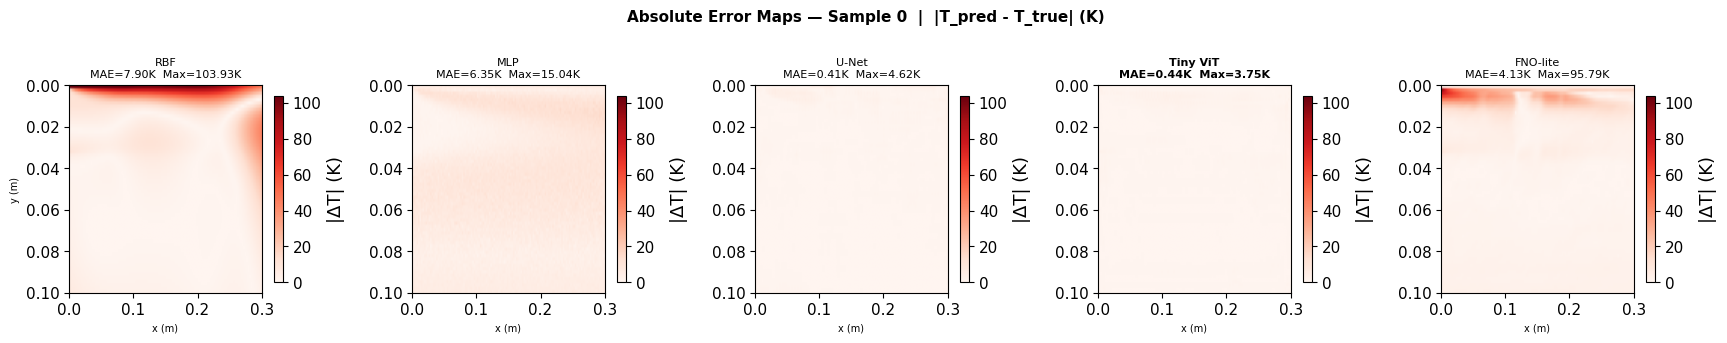

Saved: /content/drive/MyDrive/PaperSurrogate/paperReconstruction/results1/error_maps.png


In [ ]:
fig, axes = plt.subplots(1, n_models, figsize=(n_models*3.5, 3.5))
fig.suptitle('Absolute Error Maps — Sample 0  |  |T_pred - T_true| (K)',
             fontsize=11, fontweight='bold')

target_K = all_targets[0]
max_err  = max(np.abs(all_preds[n][0] - target_K).max() for n in MODEL_NAMES)
extent   = [0, 0.3, 0.1, 0]

for ax, name in zip(axes, MODEL_NAMES):
    err = np.abs(all_preds[name][0] - target_K)
    im  = ax.imshow(err, cmap='Reds', origin='upper',
                    extent=extent, aspect='auto', vmin=0, vmax=max_err)
    ax.set_title(f'{name}\nMAE={err.mean():.2f}K  Max={err.max():.2f}K',
                 fontsize=8, fontweight='bold' if name=='Tiny ViT' else 'normal')
    ax.set_xlabel('x (m)', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.9, label='|ΔT| (K)')

axes[0].set_ylabel('y (m)', fontsize=7)
plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'error_maps.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")


## **Step 11 — Robustness Plots**

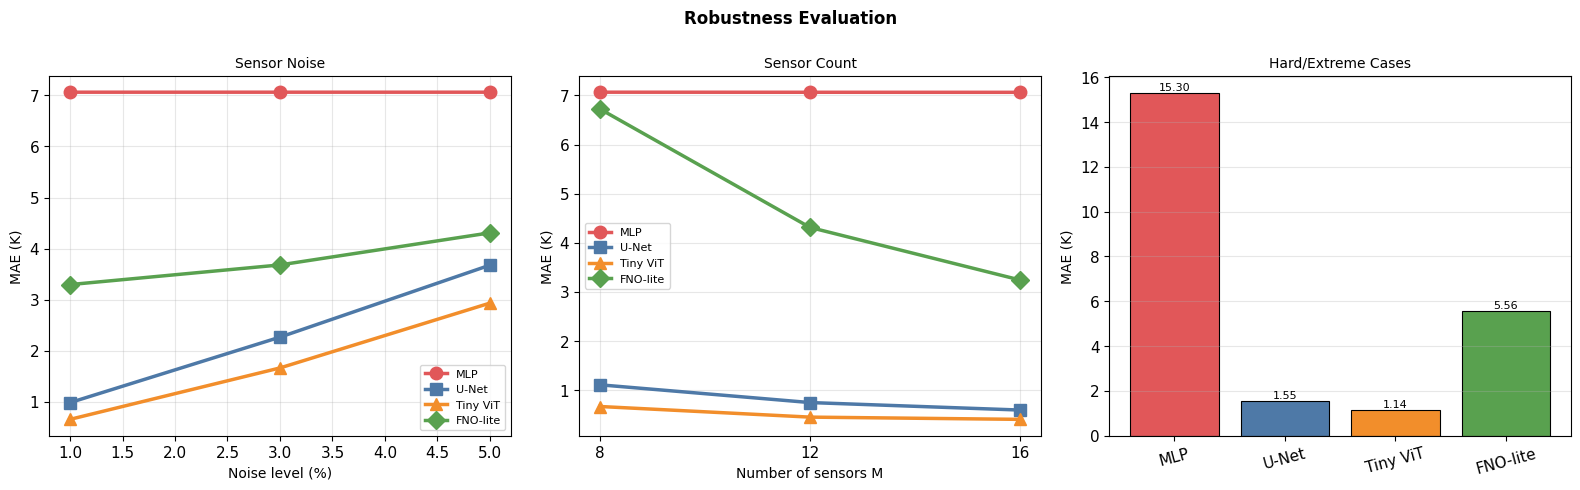

Saved: /content/drive/MyDrive/PaperSurrogate/paperReconstruction/results1/robustness_plots.png
=== Table 1 ===
 \begin{table}[h]
\centering
\caption{Reconstruction performance on the HEX test set (M=16 sensors, 500 LHS samples).
\textbf{Bold} = best per column. Tiny ViT highlighted.}
\label{tab:main}
\begin{tabular}{lccccccccc}
\hline
\textbf{Model} & \textbf{MAE} & \textbf{RMSE} & \textbf{MaxErr} & \textbf{R\textsuperscript{2}} & \textbf{SSIM} & \textbf{HotMAE} & \textbf{HDR} & \textbf{ms} & \textbf{Params} \\
& (K) & (K) & (K) & & & (K) & (\%) & & (M) \\
\hline
RBF & 7.4032 & 15.6375 & 119.89 & 0.6763 & 0.7863 & 9.7120 & 55.2362 & 3.2823 & \textbf{0.0000} \\
MLP & 7.0630 & 10.1407 & 72.5305 & 0.8639 & 0.9060 & 6.6995 & 91.0468 & \textbf{0.5251} & 27.9300 \\
U-Net & 0.5971 & 1.1577 & 32.5649 & 0.9982 & 0.9944 & 0.6245 & 98.1125 & 1.8153 & 1.9300 \\
\rowcolor{gray!15}Tiny ViT & \textbf{0.4076} & \textbf{0.7177} & \textbf{25.6648} & \textbf{0.9993} & \textbf{0.9960} & \textbf{0.5000} & 

In [ ]:
import matplotlib.ticker as ticker

rob_pivot = robustness_df.pivot(index='Setting', columns='Model', values='MAE (K)')
noise_settings  = [f'Noise {p}%' for p in [1,3,5]]
sensor_settings = [f'M={M} sensors' for M in [8,12,16]]

colors  = {'MLP':'#e15759','U-Net':'#4e79a7','Tiny ViT':'#f28e2b','FNO-lite':'#59a14f'}
markers = {'MLP':'o','U-Net':'s','Tiny ViT':'^','FNO-lite':'D'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Robustness Evaluation', fontsize=12, fontweight='bold')

# Noise
for name in models:
    vals = [rob_pivot.loc[s, name] for s in noise_settings]
    axes[0].plot([1,3,5], vals, color=colors[name], marker=markers[name],
                 lw=2.5, markersize=9, label=name)
axes[0].set_xlabel('Noise level (%)', fontsize=10)
axes[0].set_ylabel('MAE (K)', fontsize=10)
axes[0].set_title('Sensor Noise', fontsize=10); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Sensor count
for name in models:
    vals = [rob_pivot.loc[s, name] for s in sensor_settings]
    axes[1].plot([8,12,16], vals, color=colors[name], marker=markers[name],
                 lw=2.5, markersize=9, label=name)
axes[1].set_xlabel('Number of sensors M', fontsize=10)
axes[1].set_ylabel('MAE (K)', fontsize=10)
axes[1].set_title('Sensor Count', fontsize=10)
axes[1].set_xticks([8,12,16]); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Hard cases bar
hard_vals = rob_pivot.loc['Hard cases']
bars = axes[2].bar(list(models.keys()),
                   [hard_vals[n] for n in models],
                   color=[colors[n] for n in models], edgecolor='black', lw=0.8)
axes[2].set_ylabel('MAE (K)', fontsize=10)
axes[2].set_title('Hard/Extreme Cases', fontsize=10)
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, [hard_vals[n] for n in models]):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
path = os.path.join(RESULTS_DIR, 'robustness_plots.png')
plt.savefig(path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")



## **Step 12 — LaTeX Tables**

In [ ]:
def bold(val, best, higher_better=False):
    is_best = (val >= best-1e-6) if higher_better else (val <= best+1e-6)
    fmt = f"{val:.4f}" if abs(val)<100 else f"{val:.2f}"
    return f"\\textbf{{{fmt}}}" if is_best else fmt

# ── Table 1: Main results ─────────────────────────────────────────────────────
metrics = ['MAE (K)','RMSE (K)','MaxErr (K)','R2','SSIM','HotMAE (K)','HDR (%)','Time (ms)','Params (M)']
hb      = {'R2','SSIM','HDR (%)'}
# Time/Params: 'best' taken among LEARNED models only (RBF has no params / no
# GPU inference, so it is not a fair trade-off comparison point).
_trade   = {'Time (ms)','Params (M)'}
_learned = results_df[results_df['Model'] != 'RBF']
def _best(m):
    col = _learned[m] if m in _trade else results_df[m]
    return col.max() if m in hb else col.min()
bests    = {m: _best(m) for m in metrics}

latex1 = r"""\begin{table}[h]
\centering
\caption{Reconstruction performance on the HEX test set (M=16 sensors, 500 LHS samples).
\textbf{Bold} = best per column. Tiny ViT highlighted.}
\label{tab:main}
\begin{tabular}{lccccccccc}
\hline
\textbf{Model} & \textbf{MAE} & \textbf{RMSE} & \textbf{MaxErr} & \textbf{R\textsuperscript{2}} & \textbf{SSIM} & \textbf{HotMAE} & \textbf{HDR} & \textbf{ms} & \textbf{Params} \\
& (K) & (K) & (K) & & & (K) & (\%) & & (M) \\
\hline
"""

display = {'RBF':'RBF','MLP':'MLP','U-Net':'U-Net',
           'Tiny ViT':'\\rowcolor{gray!15}Tiny ViT','FNO-lite':'FNO-lite'}

for _, row in results_df.iterrows():
    name = row['Model']
    cols = " & ".join(bold(row[m], bests[m], m in hb) for m in metrics)
    latex1 += f"{display[name]} & {cols} \\\\\n"

latex1 += "\\hline\n\\end{tabular}\n\\end{table}"
print("=== Table 1 ===\n", latex1)
with open(os.path.join(RESULTS_DIR,'table1_main.tex'),'w') as f: f.write(latex1)

# ── Table 2: Robustness ───────────────────────────────────────────────────────
rob_pivot2 = robustness_df.pivot(index='Setting', columns='Model', values='MAE (K)')
latex2 = r"""\begin{table}[h]
\centering
\caption{Robustness evaluation: MAE (K) under sensor noise, dropout, and extreme cases.}
\label{tab:robustness}
\begin{tabular}{lcccc}
\hline
\textbf{Setting} & \textbf{MLP} & \textbf{U-Net} & \textbf{Tiny ViT} & \textbf{FNO-lite} \\
\hline
"""
for setting in sorted(rob_pivot2.index):
    row = " & ".join(f"{rob_pivot2.loc[setting,n]:.3f}" for n in ['MLP','U-Net','Tiny ViT','FNO-lite'])
    latex2 += f"{setting} & {row} \\\\\n"
latex2 += "\\hline\n\\end{tabular}\n\\end{table}"
print("\n=== Table 2 ===\n", latex2)
with open(os.path.join(RESULTS_DIR,'table2_robustness.tex'),'w') as f: f.write(latex2)
print(f"\nTables saved to: {RESULTS_DIR}")



=== Table 1 ===
 \begin{table}[h]
\centering
\caption{Reconstruction performance on the HEX test set (M=16 sensors, 500 LHS samples).
\textbf{Bold} = best per column. Tiny ViT highlighted.}
\label{tab:main}
\begin{tabular}{lccccccccc}
\hline
\textbf{Model} & \textbf{MAE} & \textbf{RMSE} & \textbf{MaxErr} & \textbf{R\textsuperscript{2}} & \textbf{SSIM} & \textbf{HotMAE} & \textbf{HDR} & \textbf{ms} & \textbf{Params} \\
& (K) & (K) & (K) & & & (K) & (\%) & & (M) \\
\hline
RBF & 7.4032 & 15.6375 & 119.89 & 0.6763 & 0.7863 & 9.7120 & 55.2362 & 3.2823 & \textbf{0.0000} \\
MLP & 7.0630 & 10.1407 & 72.5305 & 0.8639 & 0.9060 & 6.6995 & 91.0468 & \textbf{0.5251} & 27.9300 \\
U-Net & 0.5971 & 1.1577 & 32.5649 & 0.9982 & 0.9944 & 0.6245 & 98.1125 & 1.8153 & 1.9300 \\
\rowcolor{gray!15}Tiny ViT & \textbf{0.4076} & \textbf{0.7177} & \textbf{25.6648} & \textbf{0.9993} & \textbf{0.9960} & \textbf{0.5000} & \textbf{98.7318} & 3.1942 & \textbf{0.7500} \\
FNO-lite & 3.2440 & 7.2418 & 113.16 & 0.9306 & 0

## **Step 13 — Files Summary**

In [ ]:

print(f"All outputs in: {RESULTS_DIR}\n")
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f)) / 1024
    icon = 'PNG' if f.endswith('.png') else ('CSV' if f.endswith('.csv') else 'TEX')
    print(f"  [{icon}] {f:<45} {size:>7.1f} KB")

All outputs in: /content/drive/MyDrive/PaperSurrogate/paperReconstruction/results1

  [PNG] error_maps.png                                  214.2 KB
  [PNG] reconstruction_comparison.png                   954.7 KB
  [CSV] results_main.csv                                  0.9 KB
  [CSV] results_robustness.csv                            1.0 KB
  [CSV] results_table.csv                                 0.9 KB
  [PNG] robustness_plots.png                             96.3 KB
  [TEX] table1_main.tex                                   1.0 KB
  [TEX] table2_robustness.tex                             0.6 KB
